## Problem Statement

### Context

In the dynamic landscape of the financial markets, the demand for accurate predictions of gold prices is crucial for investors, traders, and stakeholders. Similar to the challenges faced by business communities in the United States in identifying and attracting the right talent, predicting the future values of precious metals poses a significant challenge. The inherent volatility and complex dynamics influencing gold prices require a reliable forecasting tool.

The goal is to provide a valuable asset for individuals navigating the financial markets, ensuring they can approach the unpredictability of gold prices with confidence and strategic insight.

### Objective:

In the realm of financial markets, predicting the future value of gold and silver holds significant importance for investors, traders, and stakeholders. The challenge lies in the inherent volatility and complex dynamics influencing gold prices. To address this, the objective is to develop an accurate time series forecasting model that can predict the future prices of gold. The model should leverage historical gold and silver price data. The anticipated outcome is a robust forecasting tool that empowers stakeholders to make informed decisions and navigate the dynamic landscape of the gold market with confidence.


#### Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# Importing necessary libraries

In [1]:
# To help with reading and manipulating data
import pandas as pd
import numpy as np

# To help with data visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# To display multiple dataframes from one cell
from IPython.display import display

# To perform decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# To build a logistic regression model
from sklearn.linear_model import LinearRegression

#To build exponential smoothening models
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

# To visualize ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# To build ARIMA model
from statsmodels.tsa.arima.model import ARIMA

#  To perform date arithmetic, allowing easy calculations and manipulations
from dateutil.relativedelta import relativedelta


# To evaluate the performance of the model
from sklearn.metrics import mean_squared_error

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Loading the data

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

ModuleNotFoundError: No module named 'google'

In [2]:
df = pd.read_csv('gold_prices.csv') #Complete the code to read the data and parse_dates to automatically infer datetime format for a datetime attribute

# Data Overview

In [3]:
df.head(5) #Complete the code to view first 5 rows of the data

,Date,Price
0,08/17/2023,1915.2
1,08/16/2023,1928.3
2,08/15/2023,1935.2
3,08/14/2023,1944.0
4,08/11/2023,NaN


In [4]:
df.tail(5) #Complete the code to view last 5 rows of the data

,Date,Price
2534,08/23/2013,NaN
2535,08/22/2013,1370.8
2536,08/21/2013,1370.1
2537,08/20/2013,1372.6
2538,08/19/2013,1365.7


In [5]:
df.shape #Complete the code to find the shape of the data

(2539, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2539 entries, 0 to 2538
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2539 non-null   object 
 1   Price   2460 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.8+ KB


In [7]:
df.describe().T #Complete the code to find the statistics of the data

,count,mean,std,min,25%,50%,75%,max
Price,2460.0,1468.78435,282.977384,1049.6,1244.375,1322.15,1775.025,2069.4


In [8]:
df.isnull().sum() #Check for null values

Date      0
Price    79
dtype: int64

### Missing value treatment

In [9]:
df['Price'] = df['Price'].fillna(df['Price'].mean())  #Fill the missing values with an appropriate technique

In [10]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [11]:
df.set_index('Date',inplace=True) #Complete the code to set the date column as index

# Exploratory Data Analysis

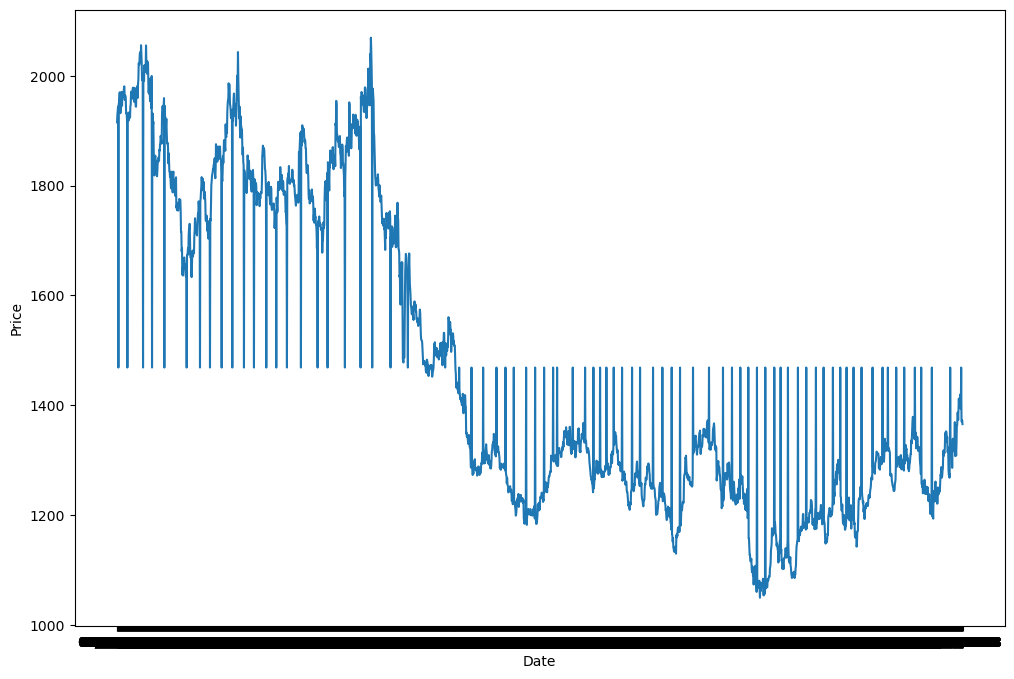

In [12]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=df, x=df.index, y='Price') # Complete the code to find the trend of the data
plt.show()

In [13]:
#We will resample the data to get values at a month-level from the day-level data by taking the average over the months.
df.index = pd.to_datetime(df.index)
df = df.resample('M').mean()
df.head()

,Price
Date,
2013-08-31,1398.908435
2013-09-30,1348.461905
2013-10-31,1324.064537
2013-11-30,1273.433333
2013-12-31,1235.049289


In [14]:
#Find the shape of the data after resampling
df.shape

(121, 1)

In [15]:
df.describe().T  #Complete the code to find the statistics of the data

,count,mean,std,min,25%,50%,75%,max
Price,121.0,1472.077843,274.950834,1086.686276,1254.056398,1330.680952,1765.860189,1997.940909


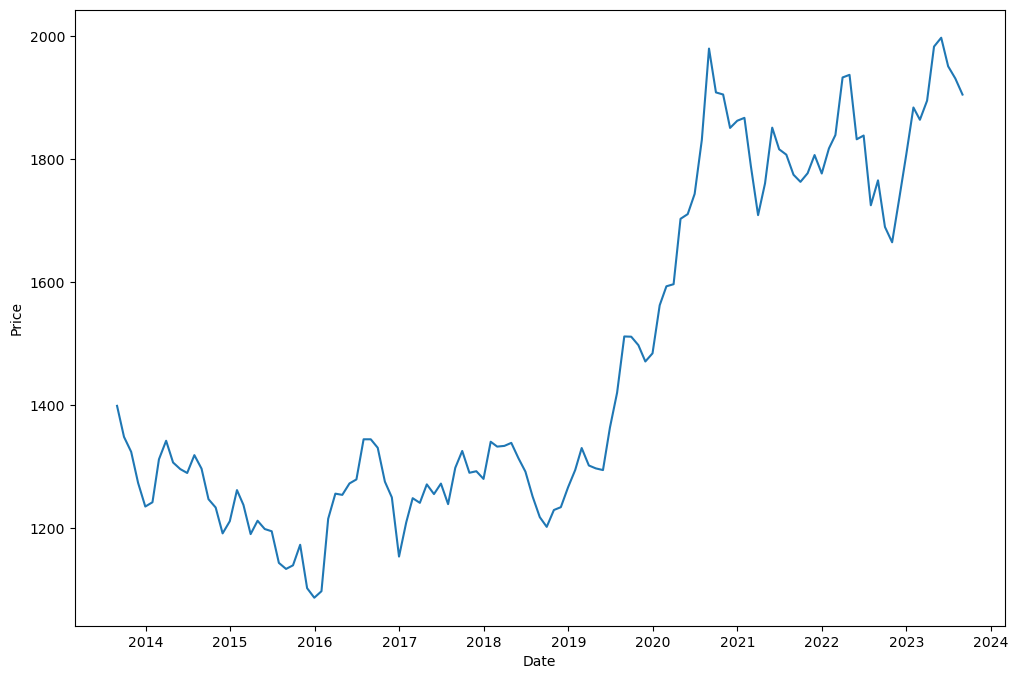

In [16]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=df, x=df.index, y='Price') # Complete the code to find the trend of price at year level
plt.show()

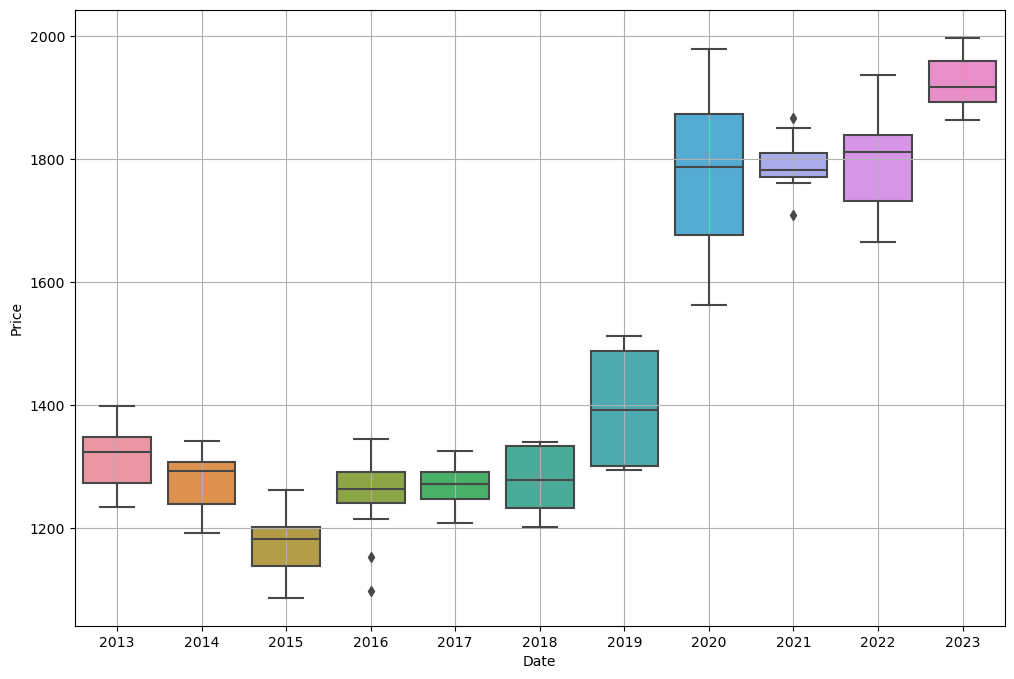

In [17]:
# Set the figure size
plt.figure(figsize=(12, 8))
sns.boxplot(x = df.index.year, y = 'Price',data=df) # Complete the code to plot a boxplot at year level
plt.grid();

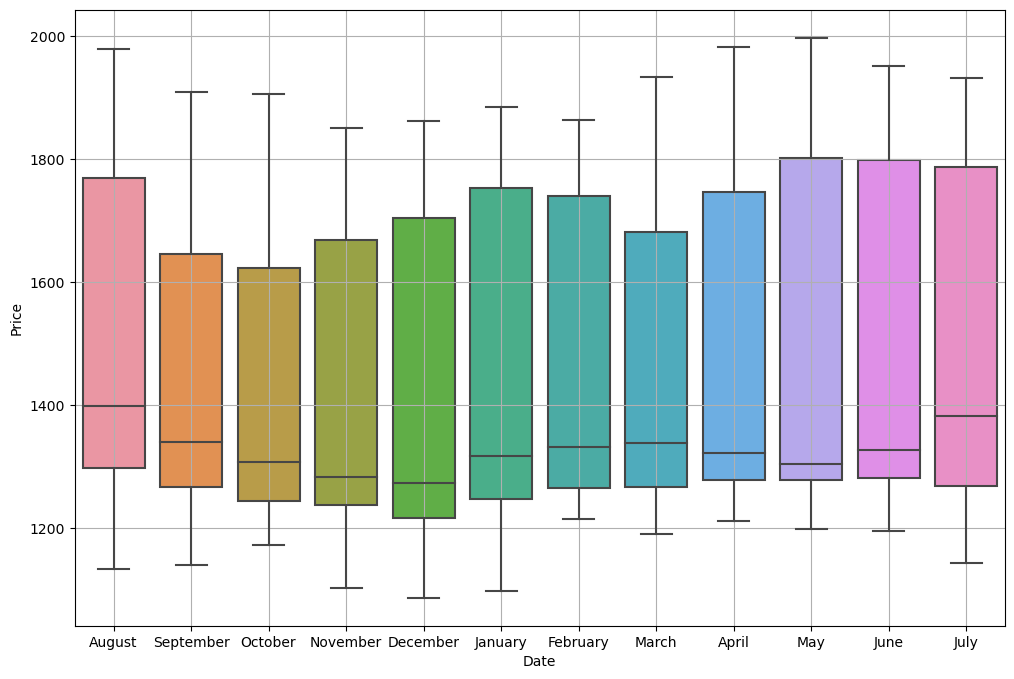

In [18]:
# Set the figure size
plt.figure(figsize=(12, 8))
sns.boxplot(x = df.index.month_name(),y = 'Price',data=df) # Complete the code to plot a boxplot at month level
plt.grid();

In [19]:
#Complete the code to create a pivot table to display monthly price across years
monthly_price_across_years = pd.pivot_table(df, values = 'Price', columns = df.index.month_name(), index = df.index.year)
monthly_price_across_years

Date,April,August,December,February,January,July,June,March,May,November,October,September
Date,,,,,,,,,,,,
2013,NaN,1398.908435,1235.049289,NaN,NaN,NaN,NaN,NaN,NaN,1273.433333,1324.064537,1348.461905
2014,1306.722016,1296.680952,1211.151493,1311.909217,1242.034783,1318.708015,1289.651636,1342.099255,1296.035652,1191.374217,1233.464537,1247.035652
2015,1211.949289,1133.542112,1086.686276,1237.649217,1261.790198,1143.381928,1194.826561,1190.208380,1198.476190,1102.213540,1172.844743,1139.390198
2016,1254.056398,1344.482609,1153.690476,1215.149217,1097.289474,1344.494217,1279.190909,1256.022016,1272.646874,1249.937350,1275.527826,1330.680952
2017,1271.136842,1298.121059,1280.014217,1248.641282,1209.089217,1238.990000,1272.422016,1241.055841,1255.344743,1292.513540,1290.017470,1325.519217
2018,1338.661905,1217.851493,1266.209217,1332.594737,1340.518302,1251.389731,1291.846874,1333.737350,1313.590198,1234.037350,1229.434102,1201.994737
2019,1297.146874,1511.818182,1484.347619,1330.272861,1294.500000,1420.322016,1363.440000,1301.871429,1294.403834,1471.104217,1497.634783,1511.449217
2020,1703.266667,1980.271429,1862.845455,1593.441282,1562.585714,1831.667470,1743.809091,1596.859091,1710.889217,1851.149217,1905.550000,1908.923064
2021,1760.909524,1774.994743,1776.981107,1788.609703,1867.557895,1807.623810,1816.403834,1709.221059,1851.620000,1807.032588,1777.428571,1763.399255


<Figure size 1500x800 with 0 Axes>

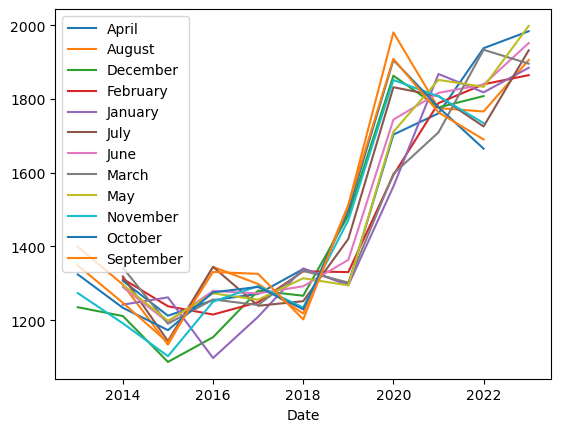

In [20]:
# Set the figure size
plt.figure(figsize=(15, 8))
monthly_price_across_years.plot()  #Complete the code to plot trend of months across years
plt.legend(loc='best')
plt.show()

### Decomposition

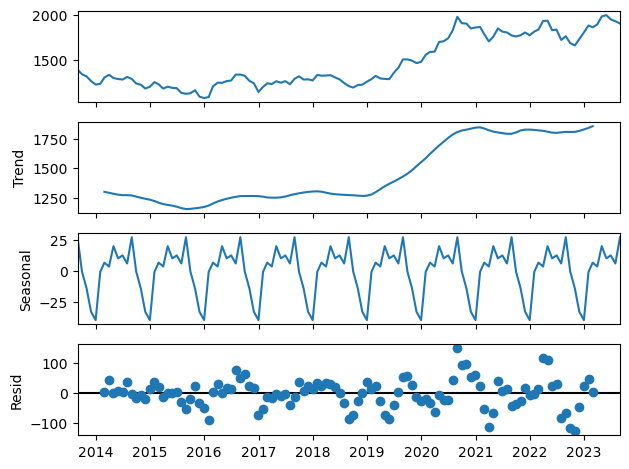

In [21]:
#Decompose the time series additively
df_add_decompose = seasonal_decompose(df, model = 'additive')  # Complete the code to decompose
df_add_decompose.plot() # Complete the code to plot
plt.show()

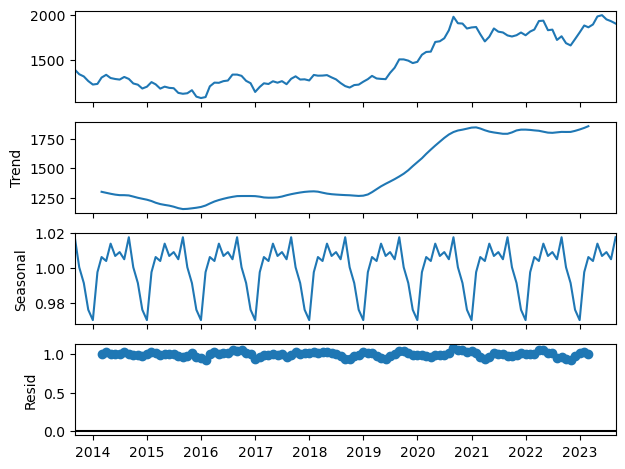

In [22]:
#Decompose the time series multiplicative
df_mul_decompose = seasonal_decompose(df, model = 'multiplicative') #Complete the code to decompose multiplicatively
df_mul_decompose.plot()   #Complte the code to plot
plt.show()

# Data Pre-processing

### Split the data into train and test and plot the training and test data.

In [23]:
#Complete the code to split train set consisting data until 2020 and test set from 2021 onwards
train = df[df.index.year < 2021]
test = df[df.index.year >= 2021]

In [24]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

First few rows of Training Data


,Price
Date,
2013-08-31,1398.908435
2013-09-30,1348.461905
2013-10-31,1324.064537
2013-11-30,1273.433333
2013-12-31,1235.049289


Last few rows of Training Data


,Price
Date,
2020-08-31,1980.271429
2020-09-30,1908.923064
2020-10-31,1905.550000
2020-11-30,1851.149217
2020-12-31,1862.845455


First few rows of Test Data


,Price
Date,
2021-01-31,1867.557895
2021-02-28,1788.609703
2021-03-31,1709.221059
2021-04-30,1760.909524
2021-05-31,1851.620000


Last few rows of Test Data


,Price
Date,
2023-04-30,1983.525492
2023-05-31,1997.940909
2023-06-30,1951.438095
2023-07-31,1931.594217
2023-08-31,1905.429565


In [25]:
#Complete the code to check the shape of train and test sets
print(train.shape)
print(test.shape)

(89, 1)
(32, 1)


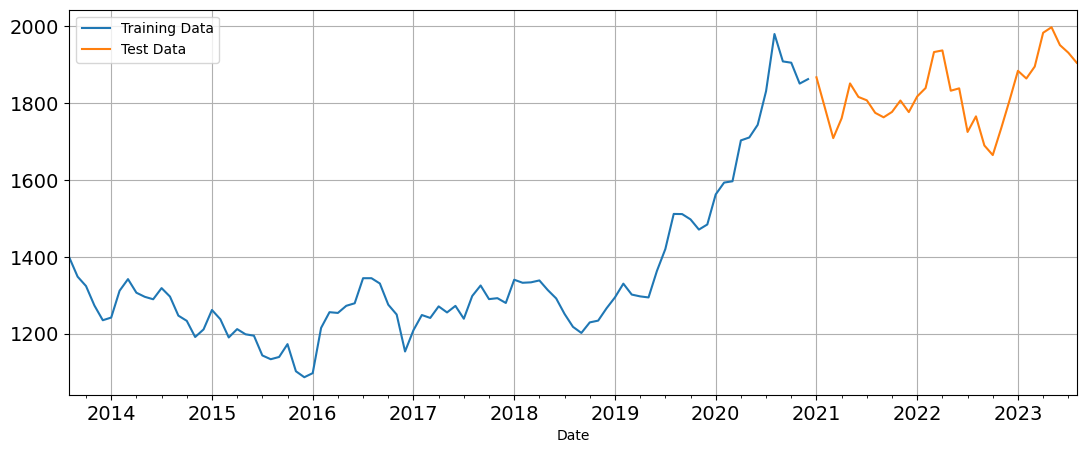

In [26]:
train['Price'].plot(figsize=(13,5), fontsize=14) #Complete the code to find the trend of train data
test['Price'].plot(figsize=(13,5), fontsize=14) #Complete the code to find the trend of test data
plt.grid()
plt.legend(['Training Data','Test Data'])
plt.show()

# Model Building - Original Data

### Linear Regression

In [27]:
#Complete the code to generate the numerical time instance order for both the training and test set.
train_time = [i+1 for i in range(len(train))]
test_time = [i+len(train) for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]
Test Time instance 
 [89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]


In [28]:
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [29]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data','\n',LinearRegression_train.head(),'\n')
print('Last few rows of Training Data','\n',LinearRegression_train.tail(),'\n')
print('First few rows of Test Data','\n',LinearRegression_test.head(),'\n')
print('Last few rows of Test Data','\n',LinearRegression_test.tail(),'\n')

First few rows of Training Data 
                   Price  time
Date                         
2013-08-31  1398.908435     1
2013-09-30  1348.461905     2
2013-10-31  1324.064537     3
2013-11-30  1273.433333     4
2013-12-31  1235.049289     5 

Last few rows of Training Data 
                   Price  time
Date                         
2020-08-31  1980.271429    85
2020-09-30  1908.923064    86
2020-10-31  1905.550000    87
2020-11-30  1851.149217    88
2020-12-31  1862.845455    89 

First few rows of Test Data 
                   Price  time
Date                         
2021-01-31  1867.557895    89
2021-02-28  1788.609703    90
2021-03-31  1709.221059    91
2021-04-30  1760.909524    92
2021-05-31  1851.620000    93 

Last few rows of Test Data 
                   Price  time
Date                         
2023-04-30  1983.525492   116
2023-05-31  1997.940909   117
2023-06-30  1951.438095   118
2023-07-31  1931.594217   119
2023-08-31  1905.429565   120 



* Now that our training and test data has been modified, let us go ahead use  𝐿𝑖𝑛𝑒𝑎𝑟𝑅𝑒𝑔𝑟𝑒𝑠𝑠𝑖𝑜𝑛
  to build the model on the training data and test the model on the test data.*

In [30]:
lr = LinearRegression() #Complete the code to define the linear regression model

In [31]:
lr.fit(LinearRegression_train[['time']], LinearRegression_train['Price'].values)  #Complete the code to build the linear regression model

LinearRegression()

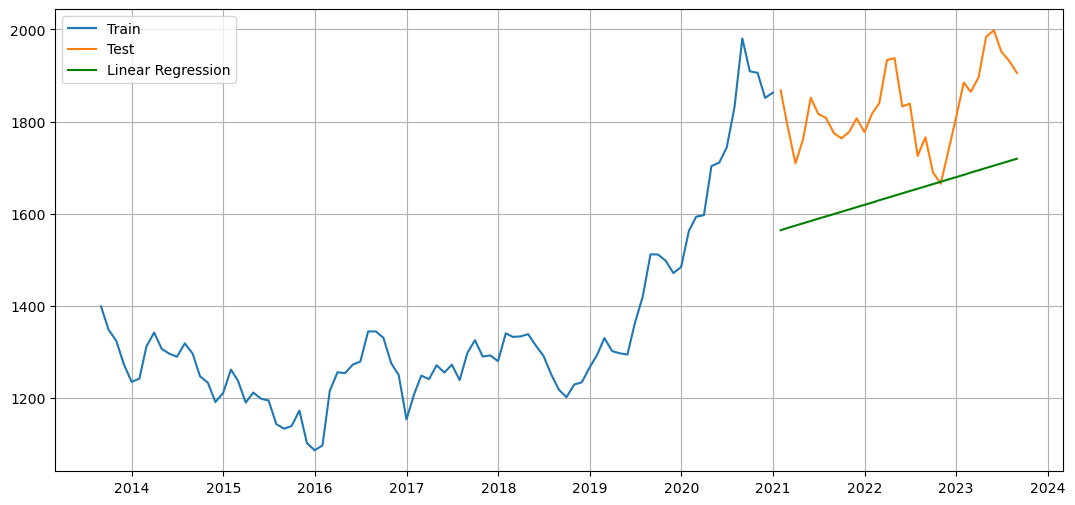

In [32]:
test_predictions_model1 = lr.predict(LinearRegression_test[['time']])  #Complete the code to make predictions
LinearRegression_test['RegOnTime'] = test_predictions_model1

plt.figure(figsize=(13,6))
plt.plot( train['Price'], label='Train')
plt.plot(test['Price'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color='green')# Complete the code to plot the predictions made by the model
plt.legend(loc='best')
plt.grid();

In [33]:
## Test Data - RMSE

rmse_model1_test = mean_squared_error(test['Price'], test_predictions_model1, squared=False)# Complete the code to find the RMSE on test data
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.2f" %(rmse_model1_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 201.18


In [34]:
resultsDf = pd.DataFrame({'Test RMSE': [rmse_model1_test]},index=['Linear Regression'])
resultsDf

,Test RMSE
Linear Regression,201.175903


### Moving Average (MA)

For the moving average model, we are going to calculate rolling means (or moving averages) for different intervals. The best interval can be determined by the maximum accuracy (or the minimum error) over here.
For Moving Average, we are going to average over the entire data.

In [35]:
MovingAverage = df.copy()
MovingAverage.head()

,Price
Date,
2013-08-31,1398.908435
2013-09-30,1348.461905
2013-10-31,1324.064537
2013-11-30,1273.433333
2013-12-31,1235.049289


In [36]:
#Trailing Moving Average

MovingAverage['Trailing_2'] = MovingAverage['Price'].rolling(2).mean() #Complete the code to find 2 point trailing average
MovingAverage['Trailing_4'] = MovingAverage['Price'].rolling(4).mean()#Complete the code to find 4 point trailing average
MovingAverage['Trailing_6'] = MovingAverage['Price'].rolling(6).mean()#Complete the code to find 6 point trailing average
MovingAverage['Trailing_9'] = MovingAverage['Price'].rolling(9).mean()#Complete the code to find 9 point trailing average

MovingAverage.head()

,Price,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Date,,,,,
2013-08-31,1398.908435,NaN,NaN,NaN,NaN
2013-09-30,1348.461905,1373.685170,NaN,NaN,NaN
2013-10-31,1324.064537,1336.263221,NaN,NaN,NaN
2013-11-30,1273.433333,1298.748935,1336.217052,NaN,NaN
2013-12-31,1235.049289,1254.241311,1295.252266,NaN,NaN


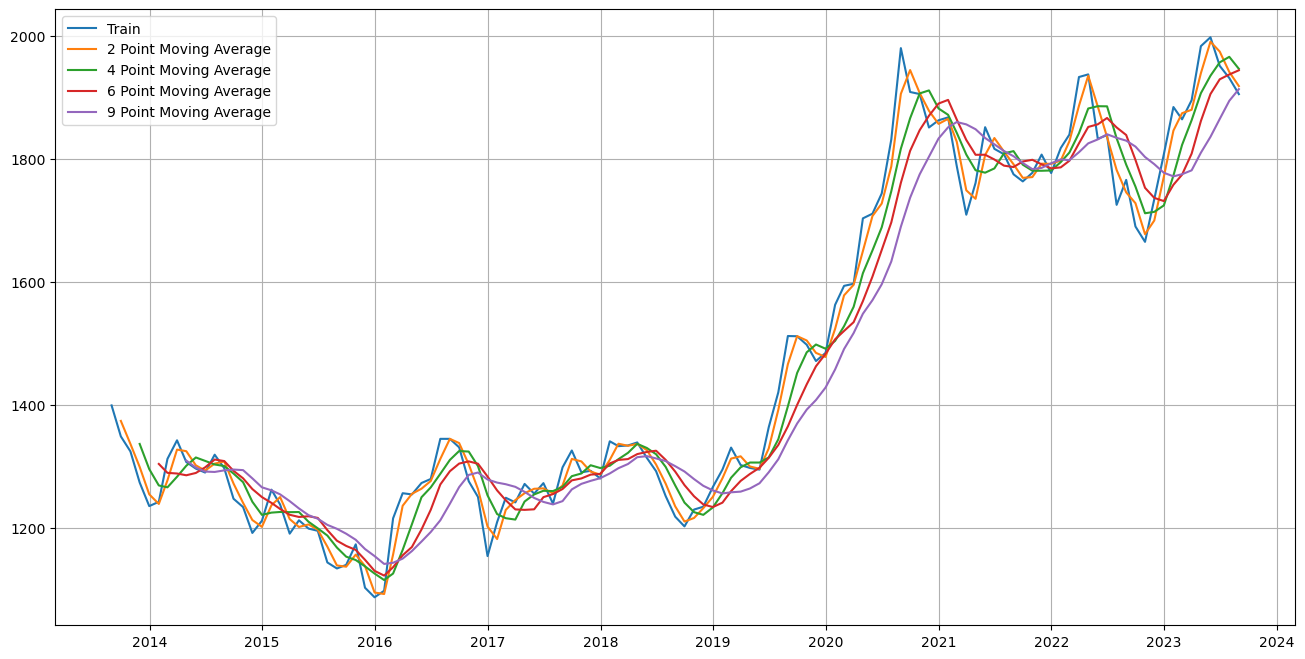

In [37]:
## Plotting on the whole data

plt.figure(figsize=(16,8))
plt.plot(MovingAverage['Price'], label='Train')
plt.plot(MovingAverage['Trailing_2'], label='2 Point Moving Average')
plt.plot(MovingAverage['Trailing_4'], label='4 Point Moving Average')
plt.plot(MovingAverage['Trailing_6'], label='6 Point Moving Average')
plt.plot(MovingAverage['Trailing_9'], label='9 Point Moving Average')

plt.legend(loc = 'best')
plt.grid();

Let us split the data into train and test and plot this Time Series. The window of the moving average is need to be carefully selected as too big a window will result in not having any test set as the whole series might get averaged over.

In [38]:
#Creating train and test set
trailing_MovingAverage_train= MovingAverage[MovingAverage.index.year < 2021]
trailing_MovingAverage_test= MovingAverage[MovingAverage.index.year >= 2021]


In [39]:
## Test Data - RMSE --> 2 point Trailing MA
from sklearn import metrics
rmse_model4_test_2 = metrics.mean_squared_error(test['Price'],trailing_MovingAverage_test['Trailing_2'],squared=False) #Complete the code to find the RMSE for 2 point moving average
print("For 2 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f" %(rmse_model4_test_2))

## Test Data - RMSE  --> 4 point Trailing MA

rmse_model4_test_4 = metrics.mean_squared_error(test['Price'],trailing_MovingAverage_test['Trailing_4'],squared=False) #Complete the code to find the RMSE for 4 point moving average
print("For 4 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f" %(rmse_model4_test_4))
## Test Data - RMSE --> 6 point Trailing MA

rmse_model4_test_6 = metrics.mean_squared_error(test['Price'],trailing_MovingAverage_test['Trailing_6'],squared=False)   #Complete the code to find the RMSE for 6 point moving average
print("For 6 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f" %(rmse_model4_test_6))
## Test Data - RMSE  --> 9 point Trailing MA

rmse_model4_test_9 = metrics.mean_squared_error(test['Price'],trailing_MovingAverage_test['Trailing_9'],squared=False)  #Complete the code to find the RMSE for 9 point moving average
print("For 9 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f" %(rmse_model4_test_9))

For 2 point Moving Average Model forecast on the Testing Data,  RMSE is 27.872
For 4 point Moving Average Model forecast on the Testing Data,  RMSE is 54.239
For 6 point Moving Average Model forecast on the Testing Data,  RMSE is 69.513
For 9 point Moving Average Model forecast on the Testing Data,  RMSE is 83.336


In [40]:
resultsDf_4 = pd.DataFrame({'Test RMSE': [rmse_model4_test_2,rmse_model4_test_4
                                          ,rmse_model4_test_6,rmse_model4_test_9]}
                           ,index=['2pointTrailingMovingAverage','4pointTrailingMovingAverage'
                                   ,'6pointTrailingMovingAverage','9pointTrailingMovingAverage'])

resultsDf = pd.concat([resultsDf, resultsDf_4])
resultsDf

,Test RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308


Before we go on to build the various Exponential Smoothing models, let us plot all the best models and compare the Time Series plots.

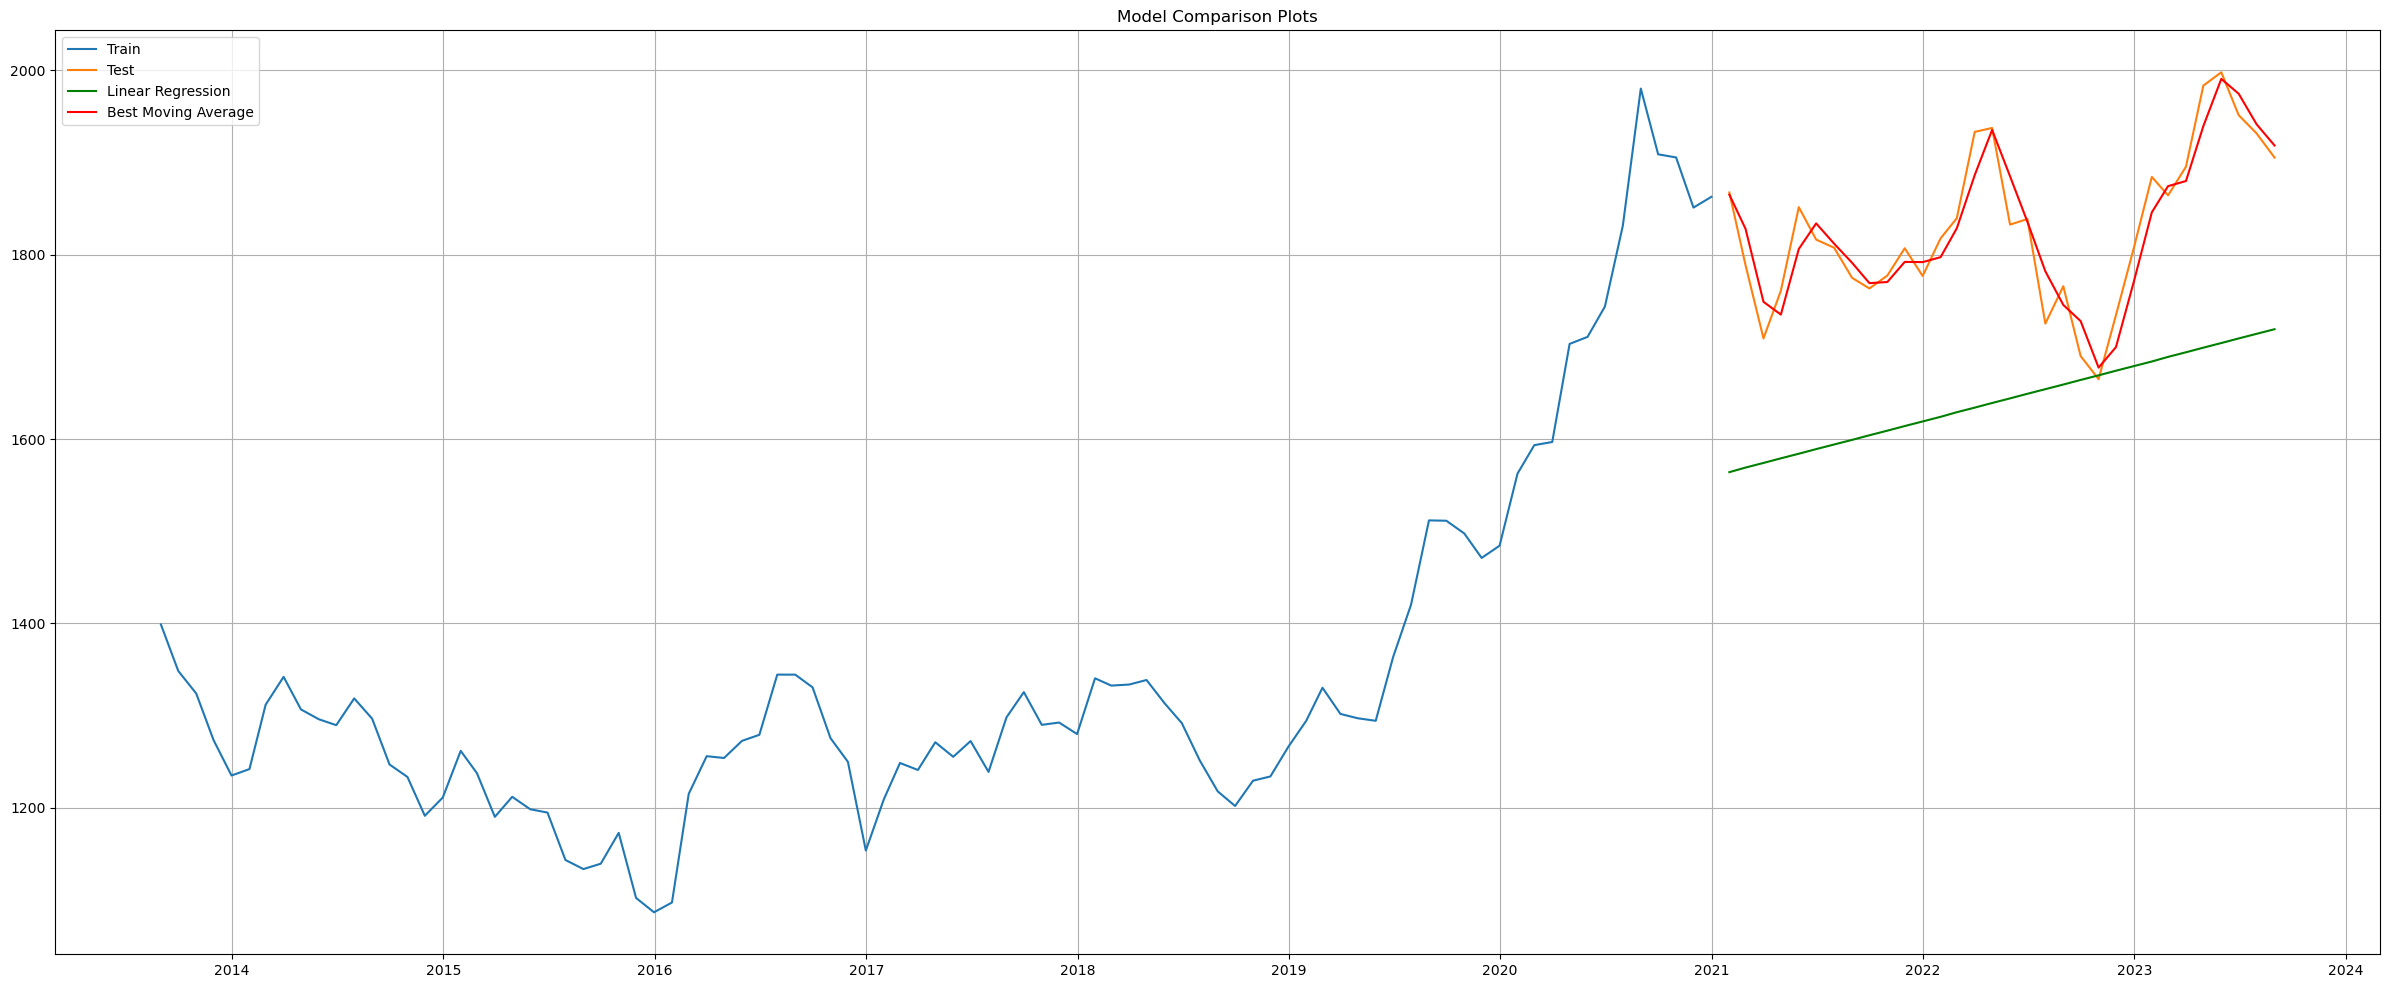

In [41]:
## Plotting on both Training and Test data

plt.figure(figsize=(30,12))
plt.plot(train['Price'], label='Train')
plt.plot(test['Price'], label='Test')

# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color='green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')


plt.legend(loc='best')
plt.title("Model Comparison Plots")
plt.grid();

### Simple Exponential Smoothening Models

In [42]:
SES_train = train.copy()
SES_test = test.copy()

In [43]:
model_SES = SimpleExpSmoothing(SES_train['Price']) #Define the simple exponential smoothening model

In [44]:
model_SES_autofit = model_SES.fit(optimized=True)   #Fit the simple exponential smoothening model

In [45]:
model_SES_autofit.params

{'smoothing_level': 0.995,
 'smoothing_trend': nan,
 'smoothing_seasonal': nan,
 'damping_trend': nan,
 'initial_level': 1398.9084349593495,
 'initial_trend': nan,
 'initial_seasons': array([], dtype=float64),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [46]:
SES_test['predict'] = model_SES_autofit.forecast(steps=len(test))   #Forecast the model
SES_test.head()

,Price,predict
Date,,
2021-01-31,1867.557895,1862.788334
2021-02-28,1788.609703,1862.788334
2021-03-31,1709.221059,1862.788334
2021-04-30,1760.909524,1862.788334
2021-05-31,1851.620000,1862.788334


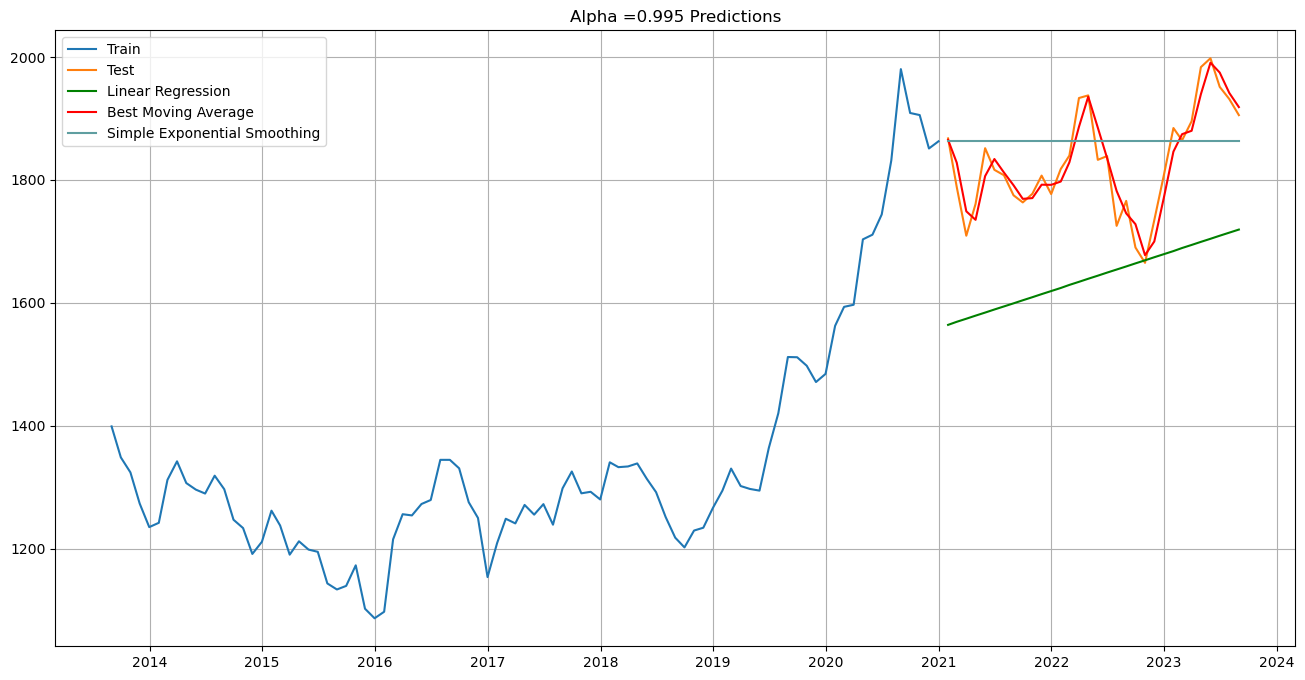

In [47]:
## Plotting on both the Training and Test data

plt.figure(figsize=(16,8))
plt.plot(SES_train['Price'], label='Train')
plt.plot(SES_test['Price'], label='Test')

# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color='green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')

#Complete the code to plot the predictions based on the simple exponential smoothening model
plt.plot(SES_test['predict'], label='Simple Exponential Smoothing', color='cadetblue')

plt.legend(loc='best')
plt.grid()
plt.title('Alpha =0.995 Predictions');

Model Evaluation for  𝛼
  = 0.995 : Simple Exponential Smoothing

In [48]:
## Test Data
#Complete the code to find the RMSE of simple exponential smoothening model
rmse_model5_test_1 = mean_squared_error(SES_test['Price'], SES_test['predict'], squared=False)
print("For Alpha =0.995 Simple Exponential Smoothing Model forecast on the Test Data, RMSE is %3.3f" %(rmse_model5_test_1))


For Alpha =0.995 Simple Exponential Smoothing Model forecast on the Test Data, RMSE is 90.187


In [49]:
resultsDf_5 = pd.DataFrame({'Test RMSE': [rmse_model5_test_1]},index=['Alpha=0.995,SimpleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_5])
resultsDf

,Test RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647


### Double Exponential Smoothening (Holt's Model)

Two parameters  𝛼
  and  𝛽
  are estimated in this model. Level and Trend are accounted for in this model.

In [50]:
DES_train = train.copy()
DES_test = test.copy()

In [51]:
model_DES = Holt(DES_train['Price']) #Define the double exponential smoothening model

In [52]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_7 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_7

,Alpha Values,Beta Values,Train RMSE,Test RMSE


In [53]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        model_DES_alpha_i_j = Holt(DES_train['Price']).fit(smoothing_level=i,smoothing_trend=j,optimized=False,use_brute=True) #fit the model
        DES_train['predict',i,j] = model_DES_alpha_i_j.fittedvalues
        DES_test['predict',i,j] = model_DES_alpha_i_j.forecast(steps=37)  #Forecast the model

        rmse_model6_train = mean_squared_error(DES_train['Price'], model_DES_alpha_i_j.fittedvalues, squared=False) #Find the RMSE on train data

        rmse_model6_test = mean_squared_error(DES_test['Price'], DES_test[('predict', i, j)], squared=False) #Find teh RMSE on test data

        resultsDf_7 = resultsDf_7._append({'Alpha Values':i,'Beta Values':j,'Train RMSE':rmse_model6_train
                                          ,'Test RMSE':rmse_model6_test}, ignore_index=True)

In [54]:
resultsDf_7.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Train RMSE,Test RMSE
61,1.0,0.8,51.956119,91.155144
54,0.9,0.9,51.786497,94.424902
40,0.8,0.3,47.464513,98.549464
57,1.0,0.4,46.863742,99.605155
48,0.9,0.3,46.391811,103.510659


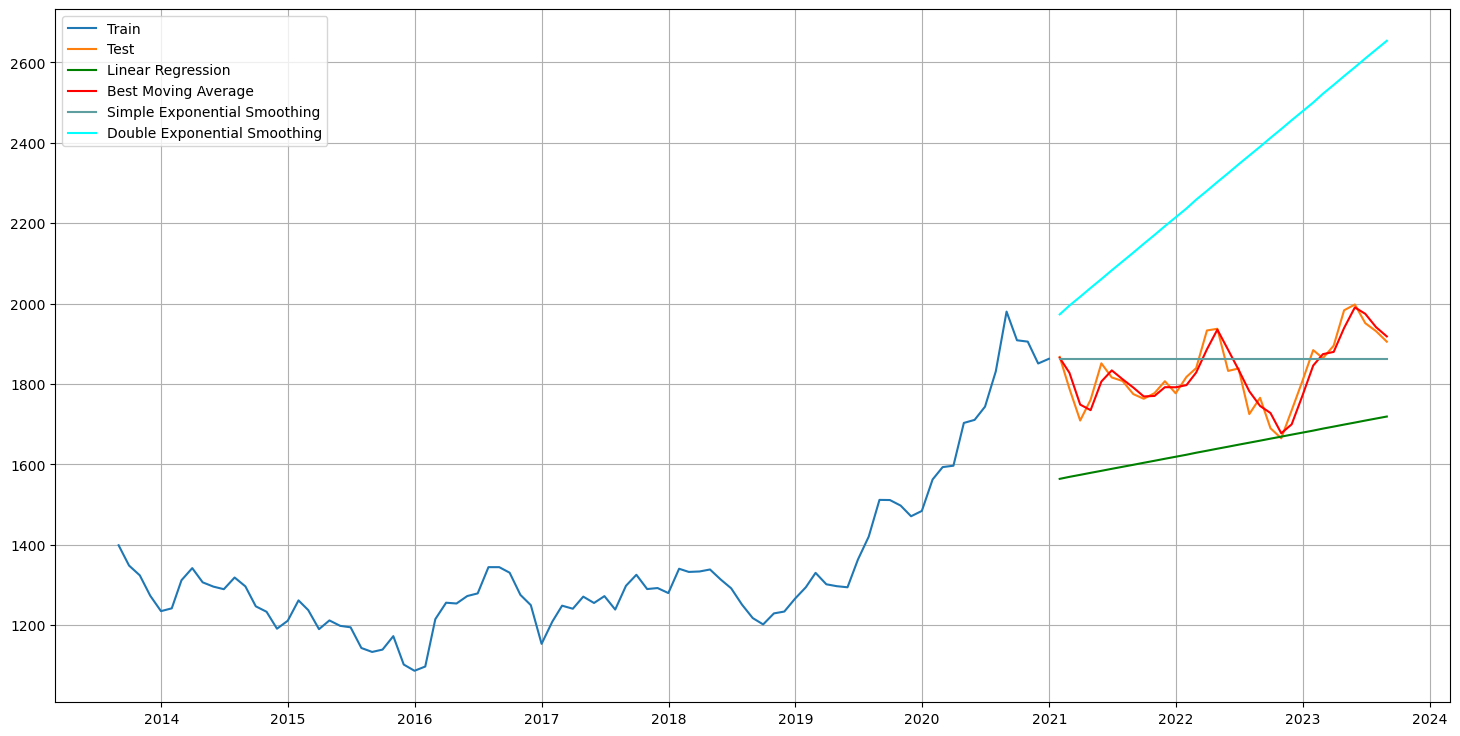

In [55]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(DES_train['Price'], label='Train')
plt.plot(DES_test['Price'], label='Test')

# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color = 'green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')

#Complete the code to plot the predictions based on the simple exponential smoothening model
plt.plot(SES_test['predict'], label='Simple Exponential Smoothing', color='cadetblue')

#Complete the code to plot the predictions based on the double exponential smoothening model
plt.plot(DES_test['predict', 0.3, 0.3], label='Double Exponential Smoothing', color='cyan')


plt.legend(loc='best')
plt.grid();

In [56]:
resultsDf_7_1 = pd.DataFrame({'Test RMSE': [resultsDf_7.sort_values(by=['Test RMSE']).values[0][3]]}
                           ,index=['Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_7_1])
resultsDf

,Test RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647
"Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing",91.155144


### Triple Exponential Smoothing (Holt - Winter's Model)

Three parameters  𝛼
 ,  𝛽
  and  𝛾
  are estimated in this model. Level, Trend and Seasonality are accounted for in this model.

In [57]:
TES_train = train.copy()
TES_test = test.copy()

In [58]:
model_TES = ExponentialSmoothing(TES_train['Price'], trend='add', seasonal='add')  #Define the triple exponential smoothening model

In [59]:
model_TES_autofit = model_TES.fit()   #Fit the triple exponential smoothening model

In [60]:
model_TES_autofit.params

{'smoothing_level': 0.9999999850988388,
 'smoothing_trend': 0.06715884181152897,
 'smoothing_seasonal': 1.0091872842263913e-10,
 'damping_trend': nan,
 'initial_level': 1356.382364654156,
 'initial_trend': -5.636954782955098,
 'initial_seasons': array([ 48.10828597,  20.91200841,   3.84520197, -35.76444479,
        -53.51949843, -17.15488926,  14.75283201,   7.84355426,
         19.00414747,   6.56431213,  13.15030297,  22.22622574]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [61]:
## Prediction on the test data

TES_test['auto_predict'] = model_TES_autofit.forecast(steps=len(TES_test))  #Forecast thetriple exponential smoothening model
TES_test.head()

,Price,auto_predict
Date,,
2021-01-31,1867.557895,1921.810997
2021-02-28,1788.609703,1976.319651
2021-03-31,1709.221059,1992.011307
2021-04-30,1760.909524,2025.772833
2021-05-31,1851.620000,2035.933931


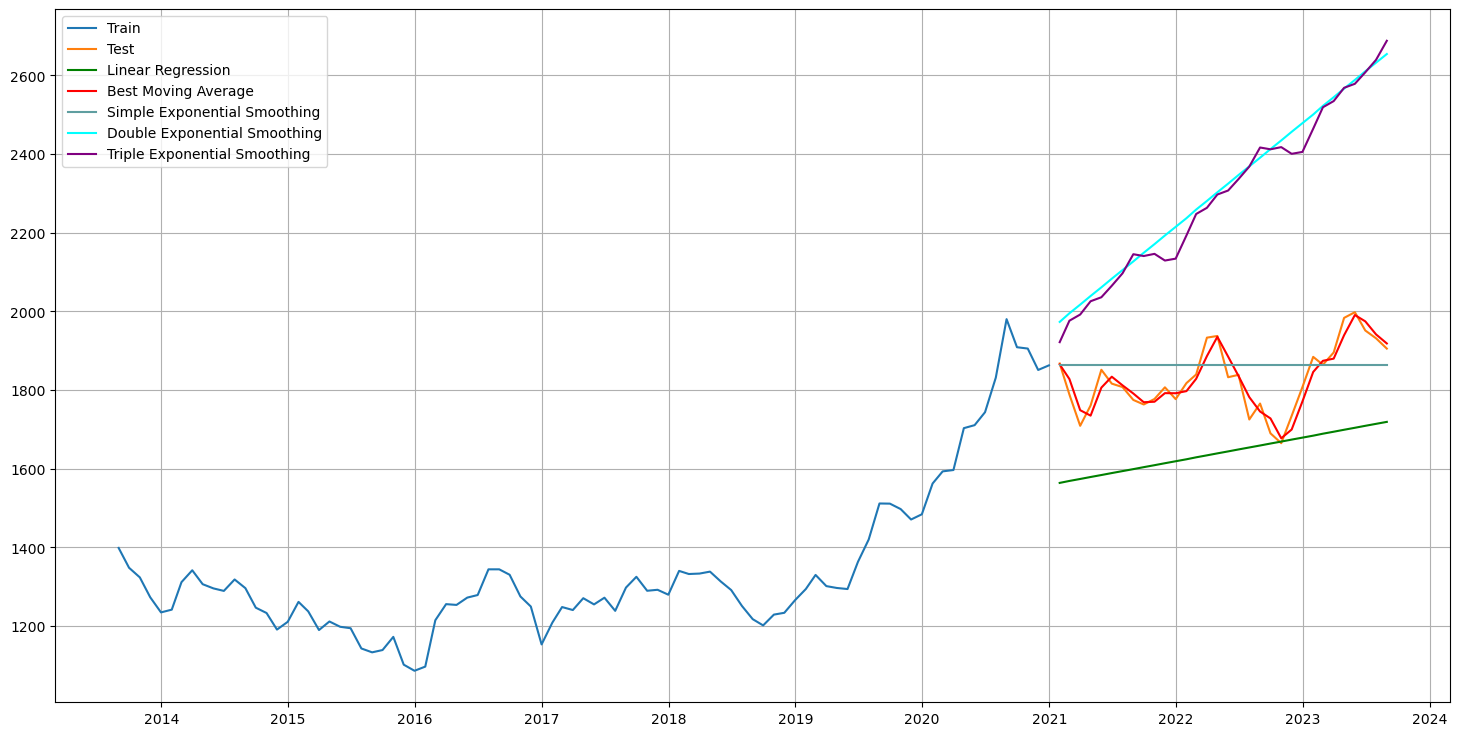

In [62]:
## Plotting on both the Training and Test using autofit

plt.figure(figsize=(18,9))
plt.plot(TES_train['Price'], label='Train')
plt.plot(TES_test['Price'], label='Test')

# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color = 'green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')

#Complete the code to plot the predictions based on the simple exponential smoothening model
plt.plot(SES_test['predict'], label='Simple Exponential Smoothing', color='cadetblue')

#Complete the code to plot the predictions based on the double exponential smoothening model
plt.plot(DES_test['predict', 0.3, 0.3], label='Double Exponential Smoothing', color='cyan')

#Complete the code to plot the predictions based on the triple exponential smoothening model
plt.plot(TES_test['auto_predict'], label='Triple Exponential Smoothing', color='purple')


plt.legend(loc='best')
plt.grid();

In [63]:
## Test Data

rmse_model6_test_1 = mean_squared_error(TES_test['Price'],TES_test['auto_predict'],squared=False) #Find the RMSE on test data
print("For Alpha=0.676,Beta=0.088,Gamma=0.323, Triple Exponential Smoothing Model forecast on the Test Data,  RMSE is %3.3f" %(rmse_model6_test_1))

For Alpha=0.676,Beta=0.088,Gamma=0.323, Triple Exponential Smoothing Model forecast on the Test Data,  RMSE is 504.694


In [64]:
resultsDf_8_1 = pd.DataFrame({'Test RMSE': [rmse_model6_test_1]}
                           ,index=['Alpha=0.676,Beta=0.088,Gamma=0.323,TripleExponentialSmoothing'])

resultsDf = pd.concat([resultsDf, resultsDf_8_1])
resultsDf

,Test RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647
"Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing",91.155144
"Alpha=0.676,Beta=0.088,Gamma=0.323,TripleExponentialSmoothing",504.694477


In [65]:
## First we will define an empty dataframe to store our values from the loop

resultsDf_8_2 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Gamma Values':[],'Train RMSE':[],'Test RMSE': []})
resultsDf_8_2

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE


In [66]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        for k in np.arange(0.3,1.1,0.1):
            model_TES_alpha_i_j_k = model_TES.fit(smoothing_level=i, smoothing_trend=j, smoothing_seasonal=k,optimized=False,use_brute='___') #Fit the model
            TES_train['predict',i,j,k] = model_TES_alpha_i_j_k.fittedvalues
            TES_test['predict',i,j,k] = model_TES_alpha_i_j_k.forecast(steps=37)    #Forecast the model

            rmse_model8_train = mean_squared_error(TES_train['Price'],TES_train['predict', i, j, k],squared=False) #Find the RMSE on train data

            rmse_model8_test = mean_squared_error(TES_test['Price'],TES_test['predict', i, j, k],squared=False) #Find the RMSE on test data

            resultsDf_8_2 = resultsDf_8_2._append({'Alpha Values':i,'Beta Values':j,'Gamma Values':k,
                                                  'Train RMSE':rmse_model8_train,'Test RMSE':rmse_model8_test}
                                                 , ignore_index=True)

In [67]:
resultsDf_8_2.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Test RMSE
355,0.8,0.7,0.6,71.777638,94.104803
297,0.7,0.8,0.4,57.325899,100.230008
404,0.9,0.5,0.7,79.889471,102.354309
338,0.8,0.5,0.5,55.269756,104.018940
248,0.6,1.0,0.3,56.528514,104.240545


In [68]:
list(TES_test.columns)

['Price',
 'auto_predict',
 ('predict', 0.3, 0.3, 0.3),
 ('predict', 0.3, 0.3, 0.4),
 ('predict', 0.3, 0.3, 0.5),
 ('predict', 0.3, 0.3, 0.6000000000000001),
 ('predict', 0.3, 0.3, 0.7000000000000002),
 ('predict', 0.3, 0.3, 0.8000000000000003),
 ('predict', 0.3, 0.3, 0.9000000000000001),
 ('predict', 0.3, 0.3, 1.0000000000000002),
 ('predict', 0.3, 0.4, 0.3),
 ('predict', 0.3, 0.4, 0.4),
 ('predict', 0.3, 0.4, 0.5),
 ('predict', 0.3, 0.4, 0.6000000000000001),
 ('predict', 0.3, 0.4, 0.7000000000000002),
 ('predict', 0.3, 0.4, 0.8000000000000003),
 ('predict', 0.3, 0.4, 0.9000000000000001),
 ('predict', 0.3, 0.4, 1.0000000000000002),
 ('predict', 0.3, 0.5, 0.3),
 ('predict', 0.3, 0.5, 0.4),
 ('predict', 0.3, 0.5, 0.5),
 ('predict', 0.3, 0.5, 0.6000000000000001),
 ('predict', 0.3, 0.5, 0.7000000000000002),
 ('predict', 0.3, 0.5, 0.8000000000000003),
 ('predict', 0.3, 0.5, 0.9000000000000001),
 ('predict', 0.3, 0.5, 1.0000000000000002),
 ('predict', 0.3, 0.6000000000000001, 0.3),
 ('predi

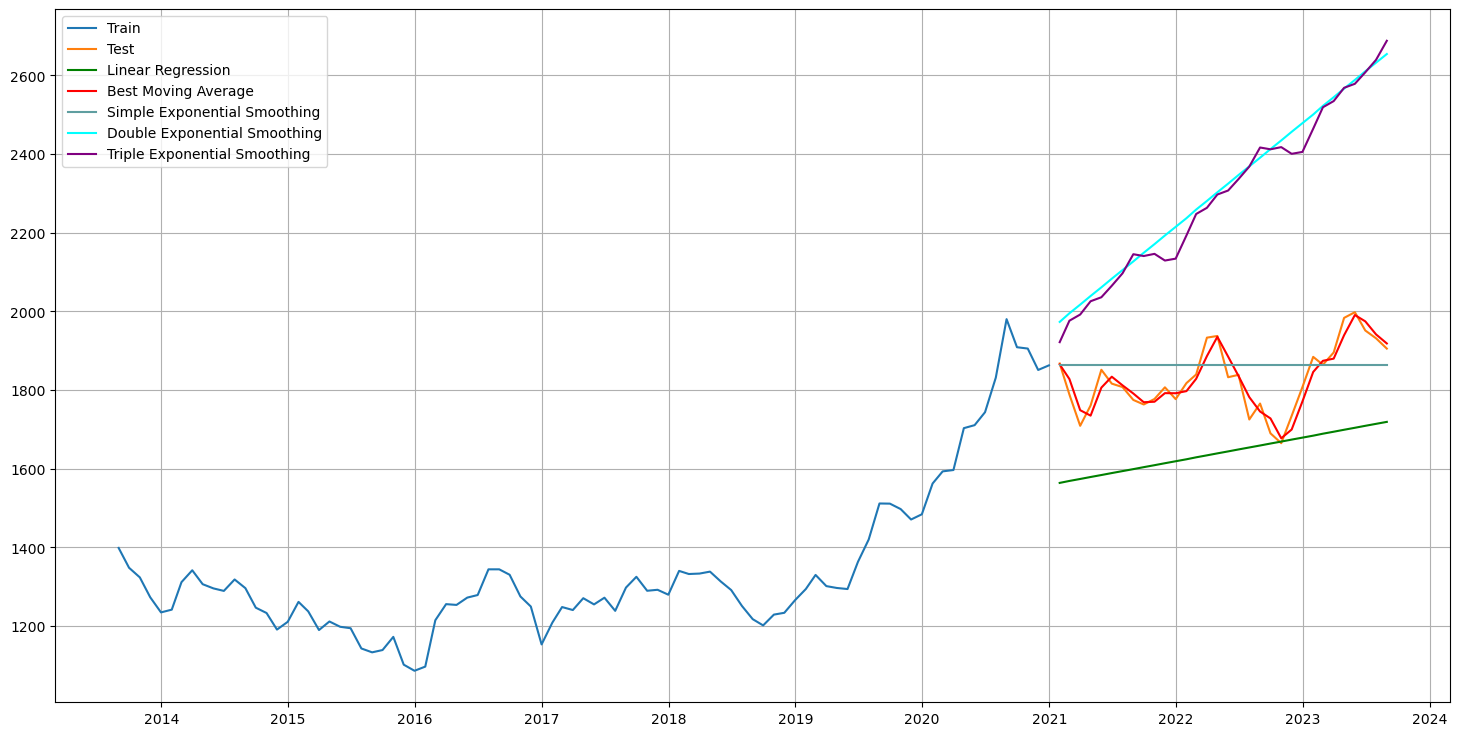

In [69]:
## Plotting on both the Training and Test data using brute force alpha, beta and gamma determination

plt.figure(figsize=(18,9))
plt.plot(TES_train['Price'], label='Train')
plt.plot(TES_test['Price'], label='Test')


# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color = 'green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')

#Complete the code to plot the predictions based on the simple exponential smoothening model
plt.plot(SES_test['predict'], label='Simple Exponential Smoothing', color='cadetblue')

#Complete the code to plot the predictions based on the double exponential smoothening model
plt.plot(DES_test['predict', 0.3, 0.3], label='Double Exponential Smoothing', color='cyan')

#Complete the code to plot the predictions based on the triple exponential smoothening model
plt.plot(TES_test['auto_predict'], label='Triple Exponential Smoothing', color='purple')


plt.legend(loc='best')
plt.grid();

In [70]:
resultsDf_8_3 = pd.DataFrame({'Test RMSE': [resultsDf_8_2.sort_values(by=['Test RMSE']).values[0][4]]}
                           ,index=['Alpha=0.8,Beta=0.5,Gamma=0.5,TripleExponentialSmoothing'])

results_Df = pd.concat([resultsDf, resultsDf_8_3])
results_Df

,Test RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647
"Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing",91.155144
"Alpha=0.676,Beta=0.088,Gamma=0.323,TripleExponentialSmoothing",504.694477
"Alpha=0.8,Beta=0.5,Gamma=0.5,TripleExponentialSmoothing",94.104803


In [71]:
print('Sorted by RMSE values on the Test Data:','\n',)
results_Df.sort_values(by=['Test RMSE'])

Sorted by RMSE values on the Test Data: 



,Test RMSE
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647
"Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing",91.155144
"Alpha=0.8,Beta=0.5,Gamma=0.5,TripleExponentialSmoothing",94.104803
Linear Regression,201.175903
"Alpha=0.676,Beta=0.088,Gamma=0.323,TripleExponentialSmoothing",504.694477


# Check for stationarity of the whole Time Series data.

In [72]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):

    #Determing rolling statistics
    rolmean = timeseries.rolling(window=7).mean() #determining the rolling mean
    rolstd = timeseries.rolling(window=7).std()   #determining the rolling standard deviation

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

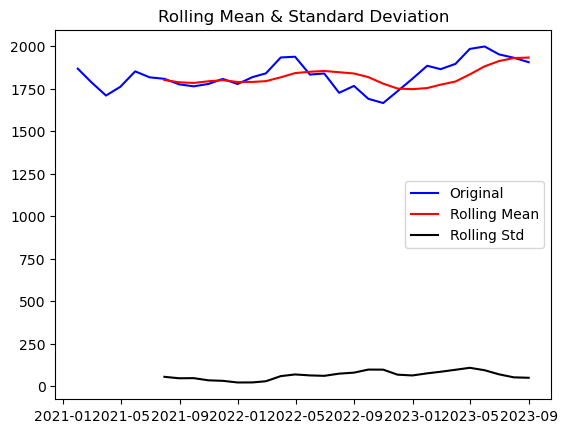

Results of Dickey-Fuller Test:
Test Statistic                 -3.237430
p-value                         0.017918
#Lags Used                      5.000000
Number of Observations Used    26.000000
Critical Value (1%)            -3.711212
Critical Value (5%)            -2.981247
Critical Value (10%)           -2.630095
dtype: float64 



In [73]:
test_stationarity(test['Price'])     #Complete the code to test stationarity on the data

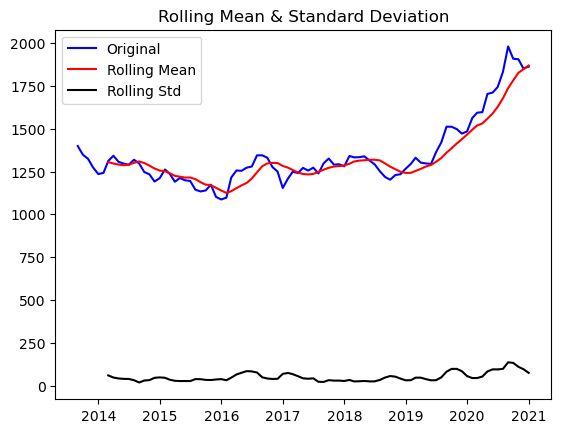

Results of Dickey-Fuller Test:
Test Statistic                  0.662224
p-value                         0.989053
#Lags Used                      0.000000
Number of Observations Used    88.000000
Critical Value (1%)            -3.506944
Critical Value (5%)            -2.894990
Critical Value (10%)           -2.584615
dtype: float64 



In [74]:
test_stationarity(train['Price'])  #Complete the code to perform differencing on train data

# Model Building - Stationary Data

### Plot the Autocorrelation and the Partial Autocorrelation function plots on the whole data.

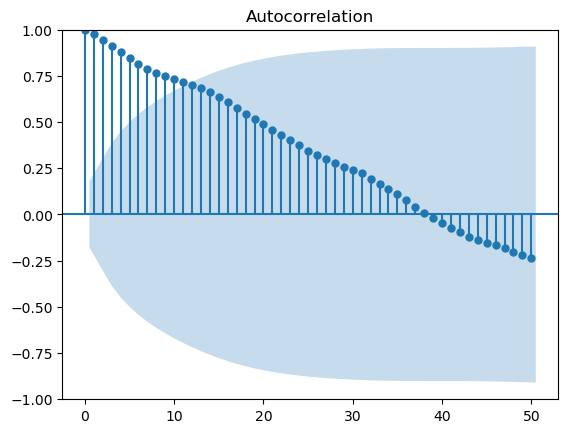

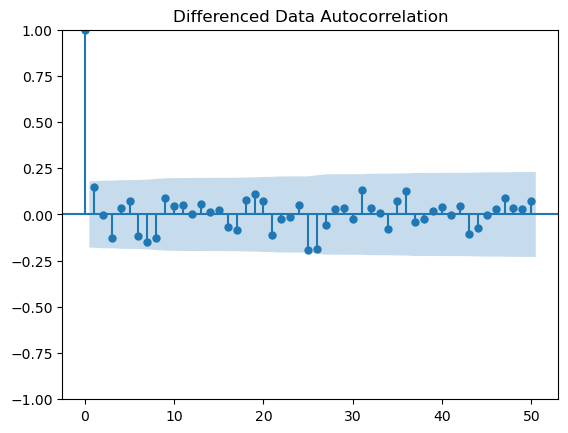

In [75]:
plot_acf(df['Price'],lags=50) #Complete the code to plot ACF plot
plot_acf(df['Price'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')  #Complete the code to plot PACF plot
plt.show()

### Auto ARIMA Model

In [76]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = q = range(0, 3)
d= [1] #complete the code to ensure stationarity
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)


In [77]:
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [78]:
for param in pdq:
    ARIMA_model = ARIMA(train['Price'],order=param).fit()  #Fit the ARIMA model
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))   #Complete the code to find the AIC values
    ARIMA_AIC = ARIMA_AIC._append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(0, 1, 0) - AIC:917.4293185297809
ARIMA(0, 1, 1) - AIC:916.4722743708096
ARIMA(0, 1, 2) - AIC:917.6698876683952
ARIMA(1, 1, 0) - AIC:916.1677536171871
ARIMA(1, 1, 1) - AIC:918.1651665718056
ARIMA(1, 1, 2) - AIC:917.4792443965465
ARIMA(2, 1, 0) - AIC:918.1615701949067
ARIMA(2, 1, 1) - AIC:918.818780687494
ARIMA(2, 1, 2) - AIC:918.4918477196446


In [79]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
3,"(1, 1, 0)",916.167754
1,"(0, 1, 1)",916.472274
0,"(0, 1, 0)",917.429319
5,"(1, 1, 2)",917.479244
2,"(0, 1, 2)",917.669888
6,"(2, 1, 0)",918.161570
4,"(1, 1, 1)",918.165167
8,"(2, 1, 2)",918.491848
7,"(2, 1, 1)",918.818781


In [80]:
auto_ARIMA = ARIMA(train['Price'], order=(1,1,0))  #Build the ARIMA model based on the best AIC values

results_auto_ARIMA = auto_ARIMA.fit()  #Fit the auto ARIMA model

print(results_auto_ARIMA.summary())   #Print the summary result

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                   89
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -456.084
Date:                Sun, 11 Aug 2024   AIC                            916.168
Time:                        14:34:58   BIC                            921.122
Sample:                    08-31-2013   HQIC                           918.164
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1911      0.083      2.294      0.022       0.028       0.354
sigma2      1857.4559    242.134      7.671      0.000    1382.882    2332.030
Ljung-Box (L1) (Q):                   0.01   Jarque-

Predict on the Test Set using this model and evaluate the model.

In [81]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))  #Forecast using the auto ARIMA
predicted_auto_ARIMA

2021-01-31    1865.081152
2021-02-28    1865.508498
2021-03-31    1865.590184
2021-04-30    1865.605798
2021-05-31    1865.608782
2021-06-30    1865.609353
2021-07-31    1865.609462
2021-08-31    1865.609483
2021-09-30    1865.609487
2021-10-31    1865.609487
2021-11-30    1865.609487
2021-12-31    1865.609488
2022-01-31    1865.609488
2022-02-28    1865.609488
2022-03-31    1865.609488
2022-04-30    1865.609488
2022-05-31    1865.609488
2022-06-30    1865.609488
2022-07-31    1865.609488
2022-08-31    1865.609488
2022-09-30    1865.609488
2022-10-31    1865.609488
2022-11-30    1865.609488
2022-12-31    1865.609488
2023-01-31    1865.609488
2023-02-28    1865.609488
2023-03-31    1865.609488
2023-04-30    1865.609488
2023-05-31    1865.609488
2023-06-30    1865.609488
2023-07-31    1865.609488
2023-08-31    1865.609488
Freq: M, Name: predicted_mean, dtype: float64

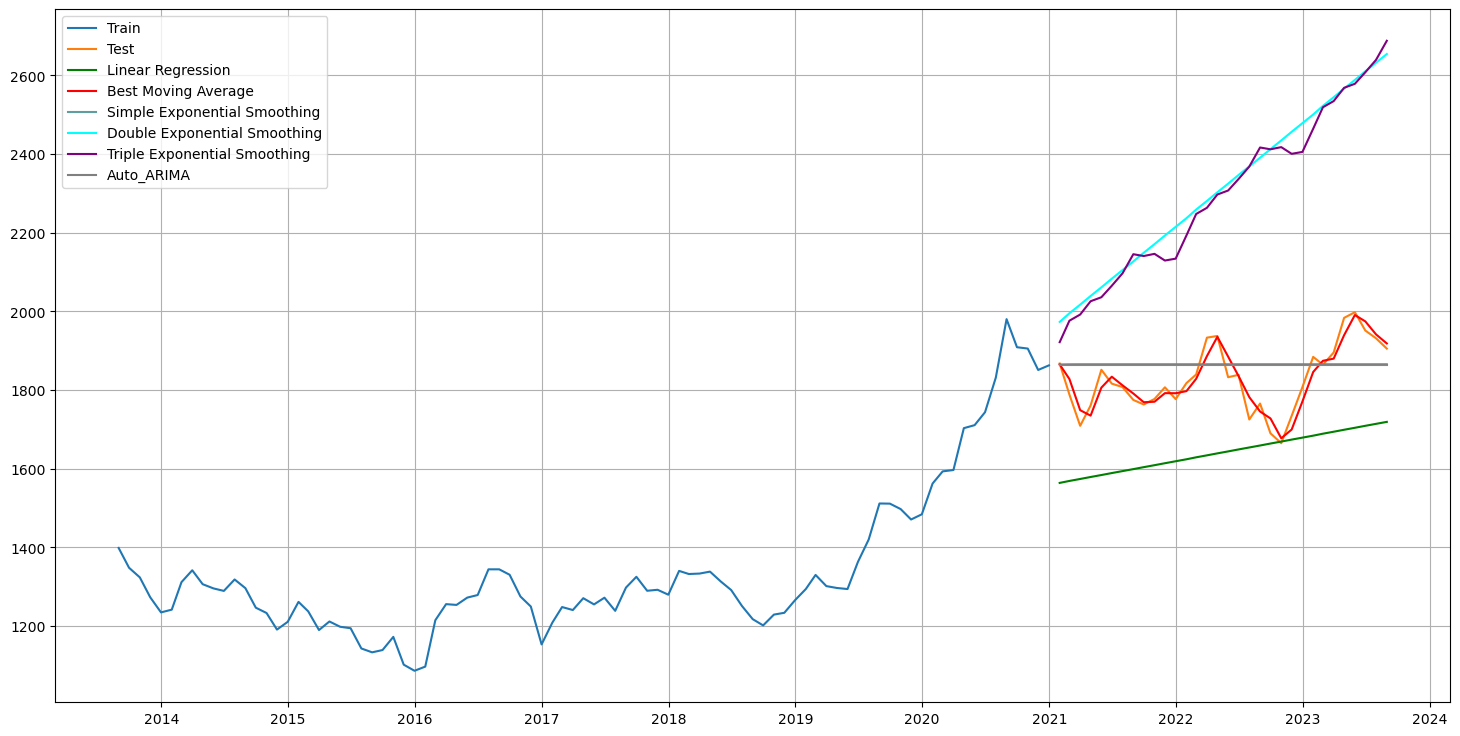

In [82]:
## Plotting on both the Training and Test using autofit

plt.figure(figsize=(18,9))
plt.plot(TES_train['Price'], label='Train')
plt.plot(TES_test['Price'], label='Test')

# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color = 'green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')

#Complete the code to plot the predictions based on the simple exponential smoothening model
plt.plot(SES_test['predict'], label='Simple Exponential Smoothing', color='cadetblue')

#Complete the code to plot the predictions based on the double exponential smoothening model
plt.plot(DES_test['predict', 0.3, 0.3], label='Double Exponential Smoothing', color='cyan')

#Complete the code to plot the predictions based on the triple exponential smoothening model
plt.plot(TES_test['auto_predict'], label='Triple Exponential Smoothing', color='purple')

#Complete the code to plot the predictions based on the Auto ARIMA model
plt.plot(test.index, predicted_auto_ARIMA, label='Auto_ARIMA', color='gray')

plt.legend(loc='best')
plt.grid();

In [83]:
rmse = mean_squared_error(test['Price'], predicted_auto_ARIMA,squared=False)  #Find the RMSE on test data
print(rmse)

91.30061851590705


In [84]:
resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['Auto_ARIMA'])

resultsDf

,RMSE
Auto_ARIMA,91.300619


### ARIMA Model

In [85]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = range(0, 3) #Define the range of AR values based on the ACF & PACF plots
q = range(0, 3)   #Define the range of AR values based on the ACF & PACF plots
d= range(0, 3)   #Define the value to make the data stationary
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 0, 1)
Model: (0, 0, 2)
Model: (0, 1, 0)
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (0, 2, 0)
Model: (0, 2, 1)
Model: (0, 2, 2)
Model: (1, 0, 0)
Model: (1, 0, 1)
Model: (1, 0, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (1, 2, 0)
Model: (1, 2, 1)
Model: (1, 2, 2)
Model: (2, 0, 0)
Model: (2, 0, 1)
Model: (2, 0, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)
Model: (2, 2, 0)
Model: (2, 2, 1)
Model: (2, 2, 2)


In [86]:
for param in pdq:
    ARIMA_model = ARIMA(train['Price'],order=param).fit() #Fit the ARIMA model
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))  #Complete the code to find teh AIC values
    ARIMA_AIC = ARIMA_AIC._append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(0, 0, 0) - AIC:1193.7374259326643
ARIMA(0, 0, 1) - AIC:1102.959679803812
ARIMA(0, 0, 2) - AIC:1034.0375805574831
ARIMA(0, 1, 0) - AIC:917.4293185297809
ARIMA(0, 1, 1) - AIC:916.4722743708096
ARIMA(0, 1, 2) - AIC:917.6698876683952
ARIMA(0, 2, 0) - AIC:949.0223047751825
ARIMA(0, 2, 1) - AIC:910.6364261937139
ARIMA(0, 2, 2) - AIC:910.7788749317984
ARIMA(1, 0, 0) - AIC:934.7439572466803
ARIMA(1, 0, 1) - AIC:933.5521487151823
ARIMA(1, 0, 2) - AIC:934.4648736669429
ARIMA(1, 1, 0) - AIC:916.1677536171871
ARIMA(1, 1, 1) - AIC:918.1651665718056
ARIMA(1, 1, 2) - AIC:917.4792443965465
ARIMA(1, 2, 0) - AIC:935.1923267932311
ARIMA(1, 2, 1) - AIC:910.7416052565202
ARIMA(1, 2, 2) - AIC:912.7197555796479
ARIMA(2, 0, 0) - AIC:933.1134887969071
ARIMA(2, 0, 1) - AIC:935.0886145430908
ARIMA(2, 0, 2) - AIC:934.8600529519323
ARIMA(2, 1, 0) - AIC:918.1615701949067
ARIMA(2, 1, 1) - AIC:918.818780687494
ARIMA(2, 1, 2) - AIC:918.4918477196446
ARIMA(2, 2, 0) - AIC:934.0415190805284
ARIMA(2, 2, 1) - AIC:912

In [87]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
16,"(0, 2, 1)",910.636426
25,"(1, 2, 1)",910.741605
17,"(0, 2, 2)",910.778875
34,"(2, 2, 1)",912.661640
26,"(1, 2, 2)",912.719756
35,"(2, 2, 2)",913.642059
21,"(1, 1, 0)",916.167754
3,"(1, 1, 0)",916.167754
1,"(0, 1, 1)",916.472274
13,"(0, 1, 1)",916.472274


In [88]:
ARIMA_model1 = ARIMA(train['Price'], order=(0, 2, 1))   #Build the ARIMA model based on the best params

results_ARIMA = ARIMA_model1.fit()  #Fit the ARIMA model

print(results_ARIMA.summary())  #Print the summary result

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                   89
Model:                 ARIMA(0, 2, 1)   Log Likelihood                -453.318
Date:                Sun, 11 Aug 2024   AIC                            910.636
Time:                        14:35:40   BIC                            915.568
Sample:                    08-31-2013   HQIC                           912.622
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9420      0.031    -30.783      0.000      -1.002      -0.882
sigma2      1918.9392    255.009      7.525      0.000    1419.131    2418.748
Ljung-Box (L1) (Q):                   1.18   Jarque-

In [89]:
predicted_ARIMA = results_ARIMA.forecast(steps=len(test))  #Forecast the ARIMA model
predicted_ARIMA

2021-01-31    1880.626516
2021-02-28    1898.407577
2021-03-31    1916.188638
2021-04-30    1933.969699
2021-05-31    1951.750760
2021-06-30    1969.531821
2021-07-31    1987.312881
2021-08-31    2005.093942
2021-09-30    2022.875003
2021-10-31    2040.656064
2021-11-30    2058.437125
2021-12-31    2076.218186
2022-01-31    2093.999247
2022-02-28    2111.780308
2022-03-31    2129.561369
2022-04-30    2147.342430
2022-05-31    2165.123491
2022-06-30    2182.904552
2022-07-31    2200.685613
2022-08-31    2218.466674
2022-09-30    2236.247735
2022-10-31    2254.028796
2022-11-30    2271.809857
2022-12-31    2289.590918
2023-01-31    2307.371979
2023-02-28    2325.153040
2023-03-31    2342.934101
2023-04-30    2360.715162
2023-05-31    2378.496223
2023-06-30    2396.277284
2023-07-31    2414.058345
2023-08-31    2431.839406
Freq: M, Name: predicted_mean, dtype: float64

In [93]:
rmse = mean_squared_error(test['Price'],predicted_ARIMA,squared=False)  #Find the RMSE on test data
print(rmse)

359.60555399606307


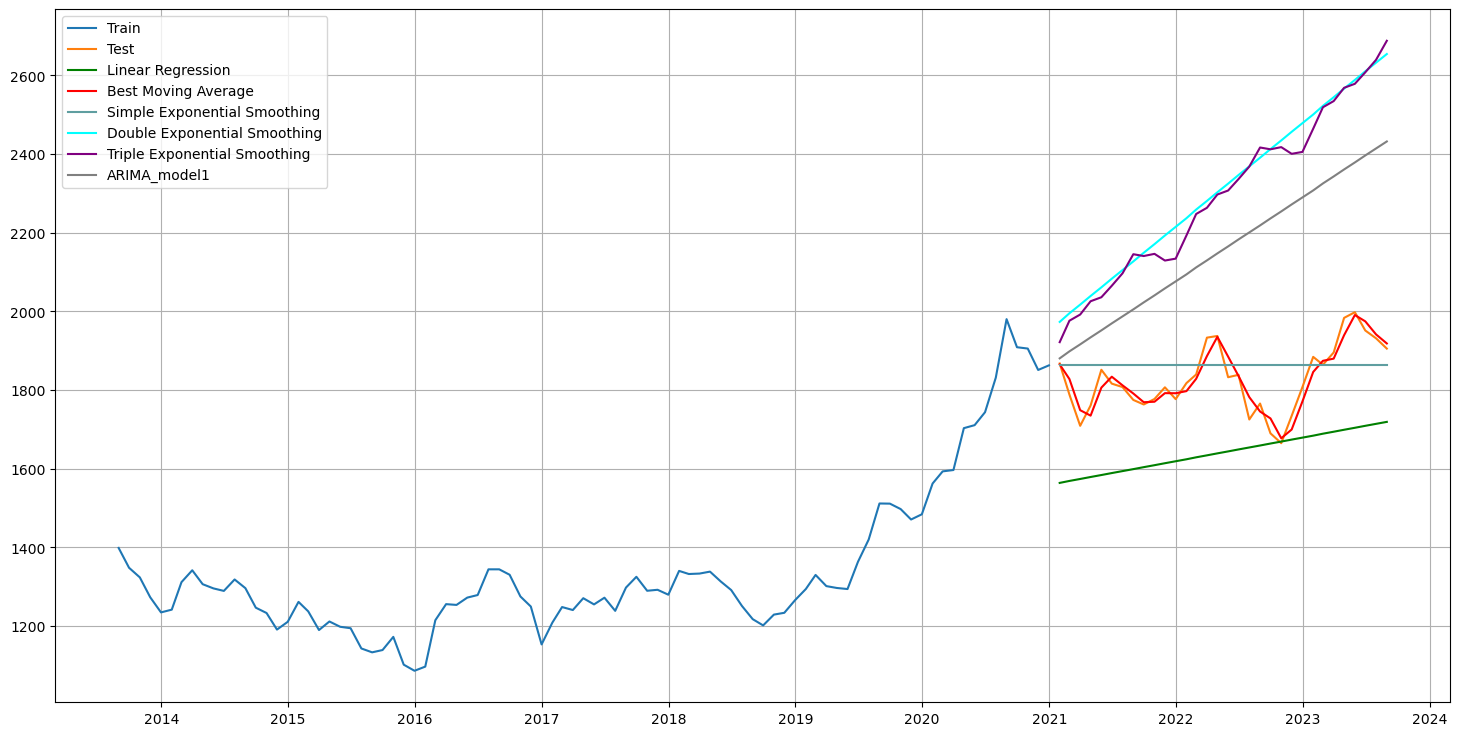

In [95]:
## Plotting on both the Training and Test using autofit

plt.figure(figsize=(18,9))
plt.plot(TES_train['Price'], label='Train')
plt.plot(TES_test['Price'], label='Test')

# Complete the code to plot the predictions made by the linear regression model
plt.plot(LinearRegression_test['RegOnTime'], label='Linear Regression', color = 'green')

#Complete the code to plot the predictions based on the best moving average model
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', color='red')

#Complete the code to plot the predictions based on the simple exponential smoothening model
plt.plot(SES_test['predict'], label='Simple Exponential Smoothing', color='cadetblue')

#Complete the code to plot the predictions based on the double exponential smoothening model
plt.plot(DES_test['predict', 0.3, 0.3], label='Double Exponential Smoothing', color='cyan')

#Complete the code to plot the predictions based on the triple exponential smoothening model
plt.plot(TES_test['auto_predict'], label='Triple Exponential Smoothing', color='purple')

#Complete the code to plot the predictions based on the ARIMA model
plt.plot(test.index, predicted_ARIMA, label='ARIMA_model1', color='gray')

plt.legend(loc='best')
plt.grid();

In [96]:
temp_resultsDf = pd.DataFrame({'RMSE': [rmse]}
                           ,index=['ARIMA_model1'])


resultsDf= pd.concat([resultsDf,temp_resultsDf])

resultsDf

,RMSE
Auto_ARIMA,91.300619
ARIMA_model1,359.605554


In [97]:
results_Df

,Test RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647
"Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing",91.155144
"Alpha=0.676,Beta=0.088,Gamma=0.323,TripleExponentialSmoothing",504.694477
"Alpha=0.8,Beta=0.5,Gamma=0.5,TripleExponentialSmoothing",94.104803


### Compare the Performance of the model & Forecast

In [101]:
results_Df.rename(columns={'Test RMSE':'RMSE'},inplace=True)
result = pd.concat([results_Df, resultsDf])
result.sort_values(by='RMSE')
result

,RMSE
Linear Regression,201.175903
2pointTrailingMovingAverage,27.871919
4pointTrailingMovingAverage,54.239048
6pointTrailingMovingAverage,69.512886
9pointTrailingMovingAverage,83.336308
"Alpha=0.995,SimpleExponentialSmoothing",90.186647
"Alpha=0.9,Beta=0.3,DoubleExponentialSmoothing",91.155144
"Alpha=0.676,Beta=0.088,Gamma=0.323,TripleExponentialSmoothing",504.694477
"Alpha=0.8,Beta=0.5,Gamma=0.5,TripleExponentialSmoothing",94.104803
Auto_ARIMA,91.300619


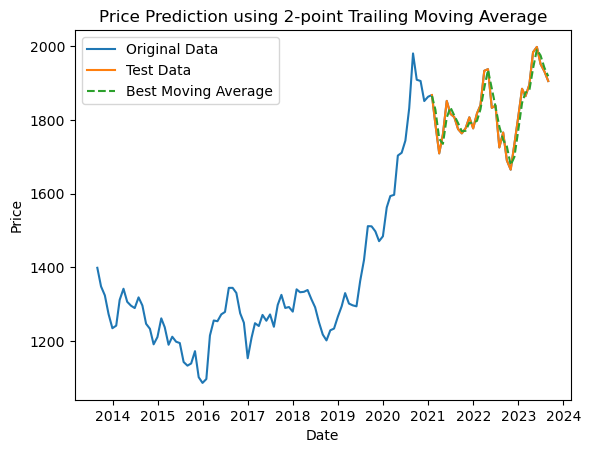

In [103]:
#Build the best model after comparing all the RMSE values


# Plot the original data and the predictions of best model
plt.plot(df['Price'], label='Original Data')
plt.plot(test['Price'], label='Test Data')
plt.plot(trailing_MovingAverage_test['Trailing_2'], label='Best Moving Average', linestyle='--')  #complete the code to plot the best model
plt.legend()
plt.title('Price Prediction using 2-point Trailing Moving Average') #Give a title to the plot
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

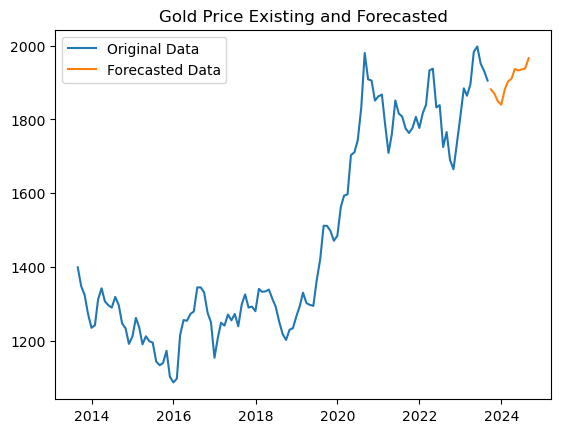

In [104]:
model_TES = ExponentialSmoothing(df['Price'], trend='add', seasonal='add', seasonal_periods=12) # Complete the code to build the best model to forecast

model_TES_alpha_i_j_k = model_TES.fit(optimized=True) # Complete the code to fit the model

predicted_results_final = model_TES_alpha_i_j_k.forecast(steps=12) # Complete the code to forecast for the next 12 months

plt.plot(df['Price'], label = 'Original Data')
plt.plot(predicted_results_final, label = 'Forecasted Data')
plt.legend(loc ='best')
plt.title('Gold Price Existing and Forecasted');